# Step 4 - Spectrum from the initial model

Synthesize the Fe I 6301/6302 Stokes spectra from the **pretrained field** (step 3): evaluate
`f_theta(x,y,z)` on the 128x128x56 grid, feed it through the forward model (P -> EOS -> ne,nHtot;
Cartesian B -> |B|,gamma,chi; vertical LOS) and the piecewise-linear polarised RT. The atmosphere is
non-magnetic (B=0), so Q,U,V ~ 0; the velocity structure imprints a Doppler pattern on Stokes I.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('.')); sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../3dtesting'))
import gpu; dev = gpu.use_gpu()               # pick the idlest GPU, no pre-alloc (BEFORE importing jax)
%matplotlib inline
import time, numpy as np, matplotlib.pyplot as plt
import atmosphere_field as af, rt_forward as rf
import jax; print('CUDA_VISIBLE_DEVICES =', dev, '| jax backend:', jax.default_backend(), jax.devices())
ATM = '/dat/milic/adora_pinn_develop/test_atm_falc_128.npz'


CUDA_VISIBLE_DEVICES = 0 | jax backend: gpu [CudaDevice(id=0)]


In [3]:
d = np.load(ATM, allow_pickle=True); z = d['z_km']
nx, ny, nz = int(d['nx']), int(d['ny']), int(d['nz'])
dz_m = np.full(nz, 20.0e3)                      # uniform 20 km layers [m]
params = af.load_params('/dat/milic/adora_pinn_develop/pretrained_field.npz')
coords = af.grid_coords(nx, ny, nz)             # matches the mock grid exactly
waves = rf.default_waves(201)
print('grid', (nx,ny,nz), ' waves', waves.shape, f'{waves[0]:.3f}..{waves[-1]:.3f} nm (vac)')

grid (128, 128, 56)  waves (201,) 630.274..630.474 nm (vac)


### Synthesize (field -> Stokes) over the full map

In [4]:
t0 = time.time()
I = np.asarray(rf.synth_field(params, coords, (nx,ny,nz), waves, dz_m, batch=4096))
print(f'Stokes cube {I.shape} in {time.time()-t0:.0f}s')
Ic = I[..., 0, 0]                               # continuum (blue edge) per pixel
print('continuum I range', f'{Ic.min():.3e} .. {Ic.max():.3e}')
print('max |V|/Ic =', f'{np.abs(I[:,:,3,:]/Ic[...,None]).max():.2e}', ' (B=0 -> ~0)')

synth: 100%|██████████| 4/4 [00:02<00:00,  1.41chunk/s]


Stokes cube (128, 128, 4, 201) in 4s
continuum I range 3.047e+01 .. 3.090e+01
max |V|/Ic = 0.00e+00  (B=0 -> ~0)


### Stokes I: mean spectrum and Doppler-shifted profiles
The two Fe I lines (6301.5, 6302.5); profiles at the strongest up/down-flow pixels are Doppler shifted.

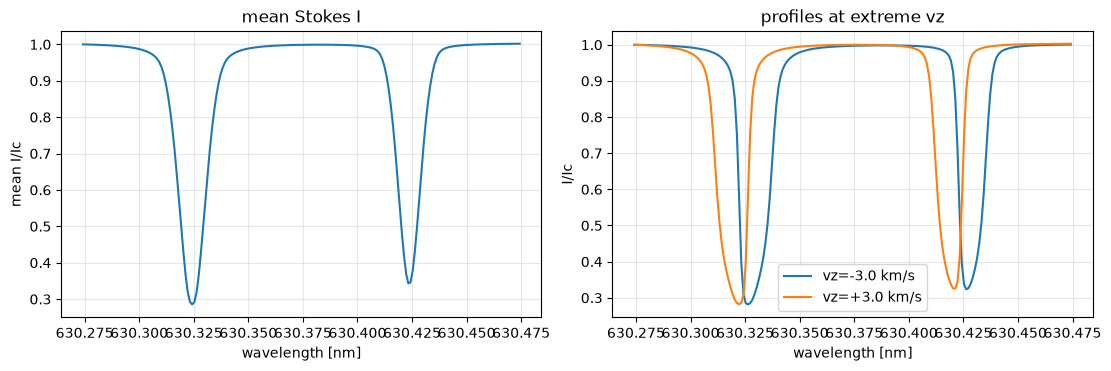

In [5]:
Inorm = I[..., 0, :] / Ic[..., None]            # I/Ic (nx,ny,nwave)
iz0 = int(np.argmin(np.abs(z - 0.0)))
vz0 = d['vz'][:, :, iz0]
pdn = np.unravel_index(np.argmax(vz0), vz0.shape); pup = np.unravel_index(np.argmin(vz0), vz0.shape)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), layout='constrained')
ax[0].plot(waves, Inorm.reshape(-1, waves.size).mean(0))
ax[0].set(xlabel='wavelength [nm]', ylabel='mean I/Ic', title='mean Stokes I'); ax[0].grid(alpha=.3)
ax[1].plot(waves, Inorm[pup], label=f'vz={vz0[pup]/1e3:+.1f} km/s')
ax[1].plot(waves, Inorm[pdn], label=f'vz={vz0[pdn]/1e3:+.1f} km/s')
ax[1].set(xlabel='wavelength [nm]', ylabel='I/Ic', title='profiles at extreme vz'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.show()

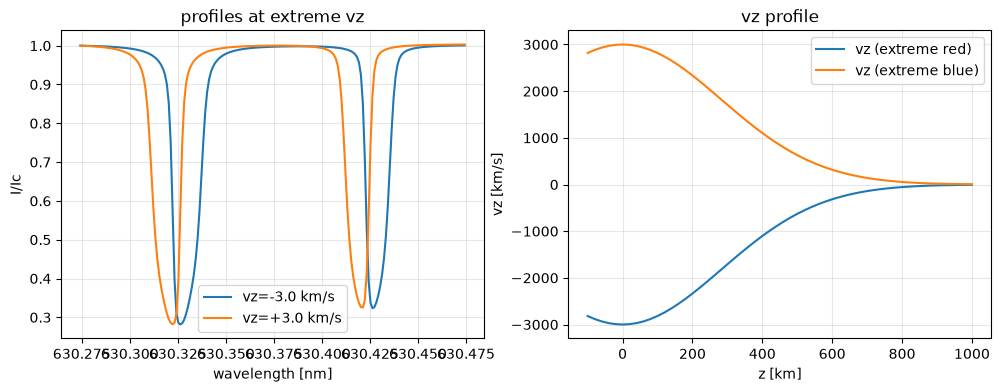

In [11]:
# sanity check: Why are the profiles at extremes like that. Plot them and their v_z profiles to investigate.
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(waves, Inorm[pup], label=f'vz={vz0[pup]/1e3:+.1f} km/s')
plt.plot(waves, Inorm[pdn], label=f'vz={vz0[pdn]/1e3:+.1f} km/s')
plt.xlabel('wavelength [nm]'); plt.ylabel('I/Ic'); plt.title('profiles at extreme vz'); plt.legend(); plt.grid(alpha=.3)
plt.subplot(1, 2, 2)
plt.plot(z, d['vz'][pup], label='vz (extreme red)')
plt.plot(z, d['vz'][pdn], label='vz (extreme blue)')
plt.xlabel('z [km]'); plt.ylabel('vz [km/s]'); plt.title('vz profile'); plt.legend(); plt.grid(alpha=.3)

### Doppler map from the spectrum vs the input velocity
Center-of-gravity velocity of the 6301.5 line recovers the granulation-like vz pattern (line-formation
weighted, so smaller amplitude than the peak input vz).

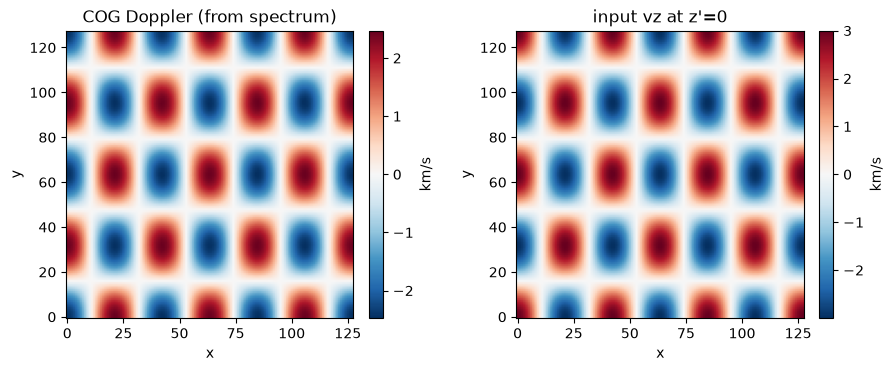

In [12]:
import lightweaver as lw
lam0 = lw.air_to_vac(630.1512); c_kms = 299792.458
w = np.abs(waves - lam0) < 0.04
depth = np.clip(1.0 - Inorm[..., w], 0.0, None)
lam_cog = (waves[w][None,None,:] * depth).sum(-1) / (depth.sum(-1) + 1e-30)
v_cog = c_kms * (lam_cog - lam0) / lam0
v_cog = v_cog - v_cog.mean()
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6), layout='constrained')
m = np.abs(v_cog).max()
im0 = ax[0].imshow(v_cog.T, origin='lower', cmap='RdBu_r', vmin=-m, vmax=m)
plt.colorbar(im0, ax=ax[0], label='km/s'); ax[0].set(title='COG Doppler (from spectrum)', xlabel='x', ylabel='y')
im1 = ax[1].imshow((vz0/1e3).T, origin='lower', cmap='RdBu_r')
plt.colorbar(im1, ax=ax[1], label='km/s'); ax[1].set(title="input vz at z'=0", xlabel='x', ylabel='y')
plt.show()

### Check: field spectrum vs the true mock atmosphere
Synth an 8x8 patch straight from the stored cube and compare to the field's spectrum there - they
agree to the pretraining accuracy, confirming the field is a faithful warm start for the RT.

In [13]:
from synth3d import synth_cube_map
n = 8
cube_patch = {'T': d['T'][:n,:n], 'Pg': d['P'][:n,:n], 'vz': d['vz'][:n,:n], 'vturb': d['vturb'][:n,:n],
              'b': np.zeros((n,n,nz)), 'gb': np.zeros((n,n,nz)), 'cb': np.zeros((n,n,nz))}
Ip = np.asarray(synth_cube_map(waves, dz_m, cube_patch, eos_mode='pg', forward_only=True, batch=n*n, progress=False))
npc = Ip[...,0,:]/Ip[...,0,:1]; nfc = I[:n,:n,0,:]/I[:n,:n,0,:1]
print(f'max |Delta(I/Ic)| field-vs-truth on 8x8 patch = {np.abs(npc-nfc).max():.2e}')

max |Delta(I/Ic)| field-vs-truth on 8x8 patch = 8.32e-03


### Summary
The pretrained field synthesizes the Fe I 6301/6302 spectra through the full forward model (EOS + piecewise-linear RT). Stokes I shows the two lines; the velocity structure produces the expected Doppler pattern (COG map ~ input vz); Q,U,V ~ 0 since B=0; and the field spectrum matches a direct synth of the mock atmosphere to the pretraining accuracy. The forward path field -> spectrum is ready for the inversion (steps 5-6).